In [2]:
import json
import re

In [ ]:
with open("llama_8b_lora_negoeval_plus_without_backfilling.json", 'r') as f:
    llama_8b_lora_without_backfilling = json.load(f)
    
with open("llama_8b_negoeval_plus_without_backfilling.json", 'r') as f:
    llama_8b_without_backfilling = json.load(f)
    
with open("llama_8b_lora_negoeval_plus.json", 'r') as f:
    llama_8b_lora = json.load(f)
        
with open("llama_8b_negoeval_plus.json", 'r') as f:
    llama_8b = json.load(f)
    
with open('actual_movement.json', 'r') as f:
    actual_movement = json.load(f)
    
countries_list = ['Austria', 'England', 'France', 'Germany', 'Italy', 'Russia', 'Turkey']

In [25]:
def dialogue_count(data):
    return len(data['intent_dialogue'].split('\n')) if data['intent_dialogue'] != "" else 0
    
def get_score_with_env(countries, prediction):
    scores = 0
    for c in countries:
        scores += prediction[c][c.upper()][1]
    score_dict = {}
    score_dict['env'] = prediction['env_uuid']
    score_dict['scores'] = scores / len(countries)
    score_dict['dialogue_count'] = dialogue_count(prediction)
    return score_dict

def get_score_dict_from_dialogue(dialogue):
    score_list = []
    for a in dialogue:
        # if a['intent_dialogue'] == "":
        #     continue
        keys = []
        for vkeys in a.keys():
            if vkeys in countries_list:
                keys.append(vkeys)
        score_list.append(get_score_with_env(keys, a))
    return score_list

def average_dialogue_count(score_list):
    dialogue_count = 0
    for i in score_list:
        dialogue_count += i['dialogue_count']
    return dialogue_count / len(score_list)

In [23]:
llama_8b_lora_without_backfilling_score_list = get_score_dict_from_dialogue(llama_8b_lora_without_backfilling)
llama_8b_without_backfilling_score_list = get_score_dict_from_dialogue(llama_8b_without_backfilling)
llama_8b_score_list = get_score_dict_from_dialogue(llama_8b)
llama_8b_lora_score_list = get_score_dict_from_dialogue(llama_8b_lora)
actual_movement_score_list = get_score_dict_from_dialogue(actual_movement)

In [26]:
llama_8b_average_dialogue_count = average_dialogue_count(llama_8b_lora_without_backfilling_score_list)
llama_8b_lora_average_dialogue_count = average_dialogue_count(llama_8b_without_backfilling_score_list)
llama_8b_without_backfilling_average_dialogue_count = average_dialogue_count(llama_8b_score_list)
llama_8b_lora_without_backfilling_average_dialogue_count = average_dialogue_count(llama_8b_lora_score_list)
actual_movement_average_dialogue_count = average_dialogue_count(actual_movement_score_list)

In [27]:
llama_8b_average_dialogue_count, llama_8b_lora_average_dialogue_count, llama_8b_without_backfilling_average_dialogue_count, llama_8b_lora_without_backfilling_average_dialogue_count, actual_movement_average_dialogue_count

(19.759336099585063,
 19.682572614107883,
 19.682572614107883,
 19.759336099585063,
 7.346473029045643)

/tmp/ipykernel_1784642/3948831973.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=values, palette="Blues_r")


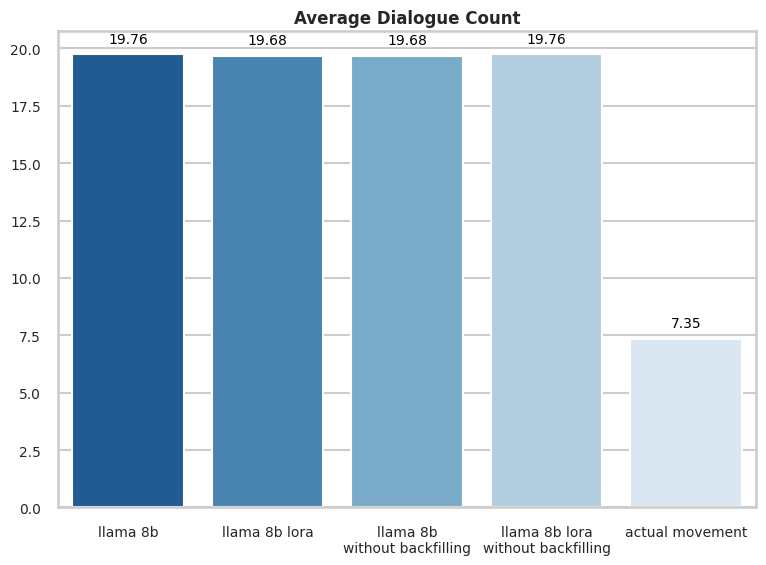

In [ ]:
# Average dialogue count plot

import matplotlib.pyplot as plt
import seaborn as sns

values = [llama_8b_average_dialogue_count, llama_8b_lora_average_dialogue_count, llama_8b_without_backfilling_average_dialogue_count, llama_8b_lora_without_backfilling_average_dialogue_count, actual_movement_average_dialogue_count]

labels = ["llama 8b", "llama 8b lora", "llama 8b\nwithout backfilling", "llama 8b lora\nwithout backfilling", "actual movement"]

sns.set_style("whitegrid")  
sns.set_context("talk")

plt.figure(figsize=(8, 6))

ax = sns.barplot(x=labels, y=values, palette="Blues_r")

for i, v in enumerate(values):
    ax.text(i, v + 0.5, f"{v:.2f}", 
            horizontalalignment='center', 
            color='black', 
            fontsize=10)

plt.title("Average Dialogue Count", fontsize=12, fontweight='bold')
# plt.xlabel("Model", fontsize=12)
# plt.ylabel("Count", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()

plt.show()
